## Question 2-Diabetes 

**Official data link (Q2):** [Box dataset](https://app.box.com/s/7qv44umhw0vnzgmoe9krfkfkv5kf2atv)

**Population:** 768 patients. **Outcome** is binary (1 = diabetes, 0 = no diabetes).

| Part | Task |
|------|------|
| **(a)** | Set **seed**, random sample **n = 25**, **mean** and **highest** Glucose vs population + **charts** |
| **(b)** | **98th percentile BMI** (sample vs population) + **charts** |
| **(c)** | **500** bootstrap samples of **150** (`replace=True`), **mean / SD / percentile (P98)** of BloodPressure vs population + **charts** + brief **report** |

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set(style="whitegrid")

_PROJECT_ROOT = Path(r"c:\Users\Rasna\Desktop\UMKC Masters\PDS\Assignemnt-2\question2")
DATA_PATH = _PROJECT_ROOT / "data" / "diabetes.csv"
if not DATA_PATH.exists():
    DATA_PATH = Path.home() / "Downloads" / "diabetes.csv"

_FIG = _PROJECT_ROOT / "figures"
_FIG.mkdir(parents=True, exist_ok=True)

pop = pd.read_csv(DATA_PATH)
pop.columns = pop.columns.str.strip()
assert len(pop) == 768, f"Expected 768 rows, got {len(pop)}"

print("Population shape:", pop.shape)
print("Figures save folder (friend-style `.../figures/`):", _FIG.resolve())
pop.head()

Population shape: (768, 9)
Charts save folder: C:\Users\Rasna\Desktop\UMKC Masters\PDS\Assignemnt-2\question2\outputs


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### (a) Seed, sample n = 25, Glucose - sample vs population + charts

**`SEED = 42`** for reproducibility. Includes **bar charts**, **KDE overlays** and **boxplots**.

Glucose — sample (n=25):
  mean = 116.6400  |  highest (max) = 183
Glucose — population (N=768):
  mean = 120.8945  |  highest (max) = 199


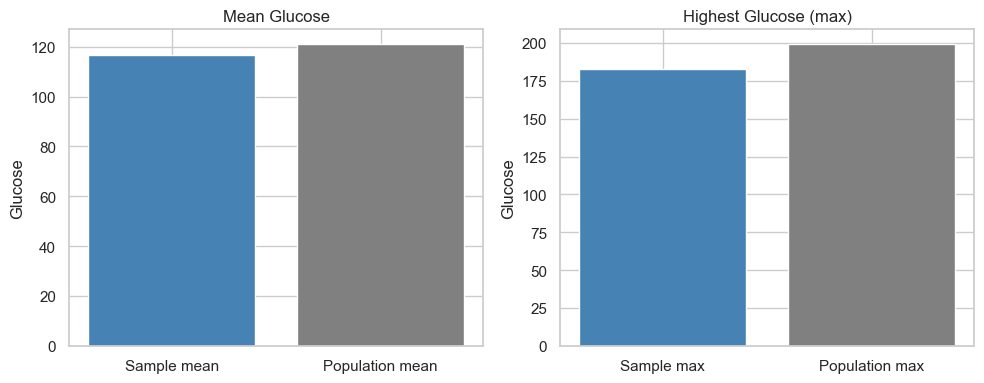

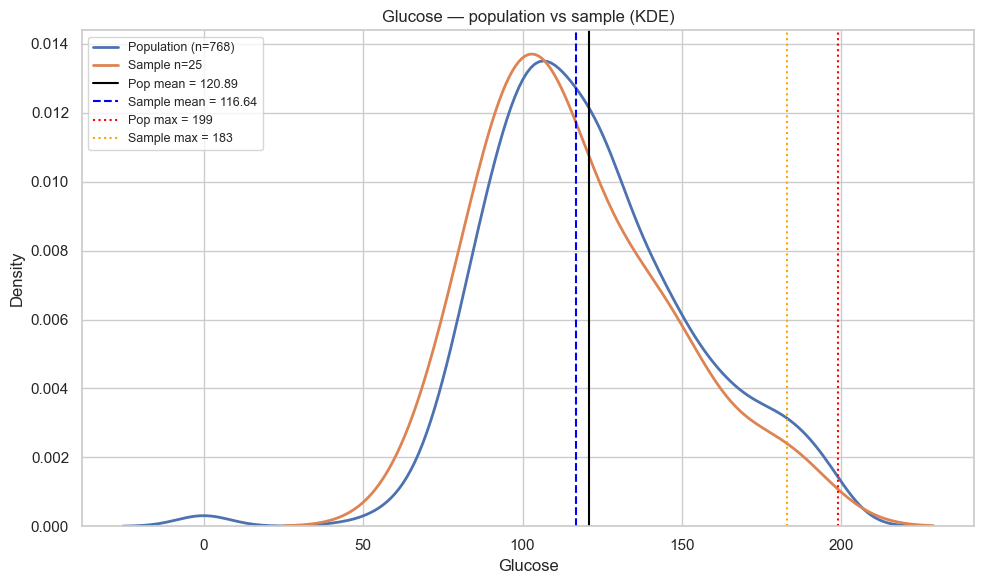

C:\Users\Rasna\AppData\Local\Temp\ipykernel_25628\2676341528.py:46: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=[pop["Glucose"], sample25["Glucose"]], palette=["#7fb3d5", "#f7b7a3"])


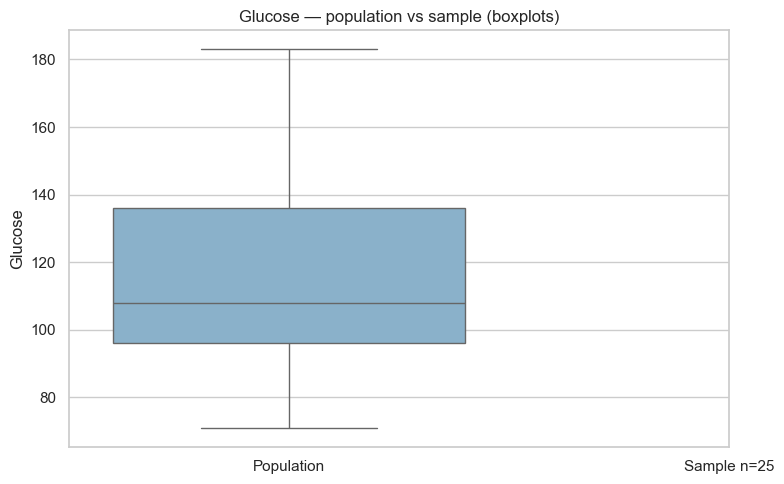

In [ ]:
SEED = 42
np.random.seed(SEED)

sample25 = pop.sample(n=25, random_state=SEED)

g_sample_mean = sample25["Glucose"].mean()
g_sample_max = sample25["Glucose"].max()
g_pop_mean = pop["Glucose"].mean()
g_pop_max = pop["Glucose"].max()

print("Glucose - sample (n=25):")
print(f"  mean = {g_sample_mean:.4f}  |  highest (max) = {g_sample_max:.0f}")
print("Glucose - population (N=768):")
print(f"  mean = {g_pop_mean:.4f}  |  highest (max) = {g_pop_max:.0f}")

# --- Bar charts ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Sample mean", "Population mean"], [g_sample_mean, g_pop_mean], color=["steelblue", "gray"])
axes[0].set_title("Mean Glucose")
axes[0].set_ylabel("Glucose")
axes[1].bar(["Sample max", "Population max"], [g_sample_max, g_pop_max], color=["steelblue", "gray"])
axes[1].set_title("Highest Glucose (max)")
axes[1].set_ylabel("Glucose")
plt.tight_layout()
plt.savefig(_FIG / "Q2a_glucose_bar_compare.png", dpi=200)
plt.show()

# --- KDE + vertical lines (distribution comparison) ---
plt.figure(figsize=(10, 6))
sns.kdeplot(pop["Glucose"], label=f"Population (n={len(pop)})", linewidth=2)
sns.kdeplot(sample25["Glucose"], label="Sample n=25", linewidth=2)
plt.axvline(g_pop_mean, color="black", linestyle="-", label=f"Pop mean = {g_pop_mean:.2f}")
plt.axvline(g_sample_mean, color="blue", linestyle="--", label=f"Sample mean = {g_sample_mean:.2f}")
plt.axvline(g_pop_max, color="red", linestyle=":", label=f"Pop max = {g_pop_max:.0f}")
plt.axvline(g_sample_max, color="orange", linestyle=":", label=f"Sample max = {g_sample_max:.0f}")
plt.title("Glucose — population vs sample (KDE)")
plt.xlabel("Glucose")
plt.ylabel("Density")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig(_FIG / "Q2a_glucose_kde_compare.png", dpi=200)
plt.show()

# --- Boxplots ---
plt.figure(figsize=(8, 5))
sns.boxplot(data=[pop["Glucose"], sample25["Glucose"]], palette=["#7fb3d5", "#f7b7a3"])
plt.xticks([0, 1], ["Population", "Sample n=25"])
plt.title("Glucose - population vs sample (boxplots)")
plt.ylabel("Glucose")
plt.tight_layout()
plt.savefig(_FIG / "Q2a_glucose_box_compare.png", dpi=200)
plt.show()

### (b) 98th percentile BMI - sample vs population + charts

Same **n = 25** sample as **(a)**. Bars plus **KDE** with vertical lines at population vs sample P98.

BMI 98th percentile — sample (n=25): 40.2480
BMI 98th percentile — population (N=768): 47.5260


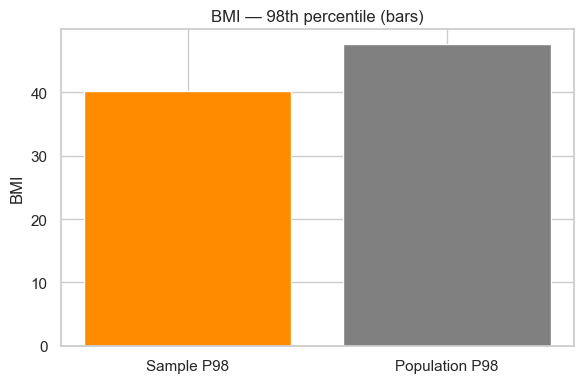

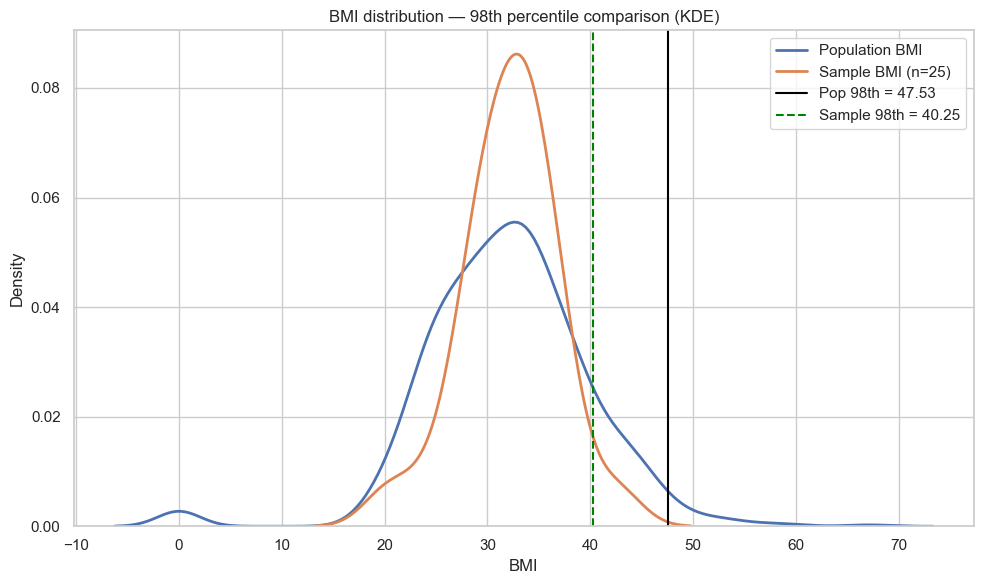

In [ ]:
# quantile(0.98) matches pandas / Colab notebooks (same as numpy percentile 98)
bmi_p98_sample = sample25["BMI"].quantile(0.98)
bmi_p98_pop = pop["BMI"].quantile(0.98)

print(f"BMI 98th percentile - sample (n=25): {bmi_p98_sample:.4f}")
print(f"BMI 98th percentile - population (N=768): {bmi_p98_pop:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Sample P98", "Population P98"], [bmi_p98_sample, bmi_p98_pop], color=["darkorange", "gray"])
ax.set_title("BMI - 98th percentile (bars)")
ax.set_ylabel("BMI")
plt.tight_layout()
plt.savefig(_FIG / "Q2b_bmi_p98_bar_compare.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(pop["BMI"], label="Population BMI", linewidth=2)
sns.kdeplot(sample25["BMI"], label="Sample BMI (n=25)", linewidth=2)
plt.axvline(bmi_p98_pop, color="black", linestyle="-", label=f"Pop 98th = {bmi_p98_pop:.2f}")
plt.axvline(bmi_p98_sample, color="green", linestyle="--", label=f"Sample 98th = {bmi_p98_sample:.2f}")
plt.title("BMI distribution - 98th percentile comparison (KDE)")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(_FIG / "Q2b_bmi_p98_compare.png", dpi=200)
plt.show()

### (c) Bootstrap BloodPressure - 500 × 150 (`replace=True`)

Per replicate: **mean**, **SD** (`ddof=1`), **98th percentile**. Average those over 500 replicates and compare to **population** mean, SD (**`ddof=1`**), and P98.

**Charts:** grouped **bars** + three **histograms** → `figures/`.

In [ ]:
SEED_BOOT = 12345
rng = np.random.default_rng(SEED_BOOT)
bp = pop["BloodPressure"].to_numpy()

N_BOOT = 500
BOOT_N = 150

boot_means = np.empty(N_BOOT)
boot_stds = np.empty(N_BOOT)
boot_p98 = np.empty(N_BOOT)

for i in range(N_BOOT):
    draw = rng.choice(bp, size=BOOT_N, replace=True)
    boot_means[i] = draw.mean()
    boot_stds[i] = draw.std(ddof=1)
    boot_p98[i] = np.percentile(draw, 98)

avg_boot_mean = boot_means.mean()
avg_boot_std = boot_stds.mean()
avg_boot_p98 = boot_p98.mean()

bp_pop_mean = float(bp.mean())
bp_pop_std = float(bp.std(ddof=1))
bp_pop_p98 = float(np.percentile(bp, 98))

print("BloodPressure - population:")
print(f"  mean={bp_pop_mean:.4f}  sd(ddof=1)={bp_pop_std:.4f}  P98={bp_pop_p98:.4f}")
print("BloodPressure — average over 500 bootstrap samples (each n=150):")
print(f"  mean of means={avg_boot_mean:.4f}  mean of sds={avg_boot_std:.4f}  mean of P98s={avg_boot_p98:.4f}")

_OUT_TBL = _PROJECT_ROOT / "outputs"
_OUT_TBL.mkdir(parents=True, exist_ok=True)
pd.DataFrame(
    {"bp_mean": boot_means, "bp_std": boot_stds, "bp_98": boot_p98}
).to_csv(_OUT_TBL / "bootstrap_bp_stats.csv", index=False)
print("Saved", (_OUT_TBL / "bootstrap_bp_stats.csv").resolve())

BloodPressure — population:
  mean=69.1055  sd(ddof=1)=19.3558  P98=99.3200
BloodPressure — average over 500 bootstrap samples (each n=150):
  mean of means=69.1359  mean of sds=19.0471  mean of P98s=97.8882


In [ ]:
labels = ["Mean", "SD", "P98"]
pop_vals = [bp_pop_mean, bp_pop_std, bp_pop_p98]
boot_vals = [avg_boot_mean, avg_boot_std, avg_boot_p98]

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w / 2, pop_vals, w, label="Population", color="gray")
ax.bar(x + w / 2, boot_vals, w, label="Avg over 500 bootstraps", color="seagreen")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_title("BloodPressure: population vs bootstrap averages")
ax.legend()
plt.tight_layout()
plt.savefig(_FIG / "Q2c_bootstrap_bp_bar_compare.png", dpi=200)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hist(boot_means, bins=30, color="#7fb3d5", edgecolor="k")
axes[0].axvline(bp_pop_mean, color="red", linestyle="--", linewidth=2, label=f"Pop mean = {bp_pop_mean:.2f}")
axes[0].set_title("Bootstrap distribution of BP means")
axes[0].legend()

axes[1].hist(boot_stds, bins=30, color="#f7b7a3", edgecolor="k")
axes[1].axvline(bp_pop_std, color="red", linestyle="--", linewidth=2, label=f"Pop sd = {bp_pop_std:.2f}")
axes[1].set_title("Bootstrap distribution of BP SDs")
axes[1].legend()

axes[2].hist(boot_p98, bins=30, color="#b7f7c7", edgecolor="k")
axes[2].axvline(bp_pop_p98, color="red", linestyle="--", linewidth=2, label=f"Pop P98 = {bp_pop_p98:.2f}")
axes[2].set_title("Bootstrap distribution of BP 98th %ile")
axes[2].legend()

plt.tight_layout()
plt.savefig(_FIG / "Q2c_bootstrap_bp_stats.png", dpi=200)
plt.show()

###Findings

- **(a)** One random sample of 25 will usually **miss** the population mean and max; KDE/boxplots show **shape** and **spread**, not only two summary numbers.
- **(b)** With **n = 25**, the sample **98th percentile** is a **noisy** tail estimate vs the population P98.
- **(c)** The **mean of bootstrap means** tracks the population mean. Histograms show **sampling variation**; red lines mark **population** reference values. The **mean of bootstrap SDs** is not required to equal the population SD (different definitions / roles).